In [14]:
# Load the California Housing dataset using the fetch_california_housing function
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [41]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()


In [43]:
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['target'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [19]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [24]:
df.shape

(20640, 9)

In [26]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')

In [28]:
df.select_dtypes(include=['float']).columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'target'],
      dtype='object')

In [21]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
target,0


In [36]:
df.skew()

,0
MedInc,1.646657
HouseAge,0.060331
AveRooms,20.697869
AveBedrms,31.316956
Population,4.935858
AveOccup,97.639561
Latitude,0.465953
Longitude,-0.297801
target,0.977763


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>,
        <Axes: title={'center': 'target'}>]], dtype=object)

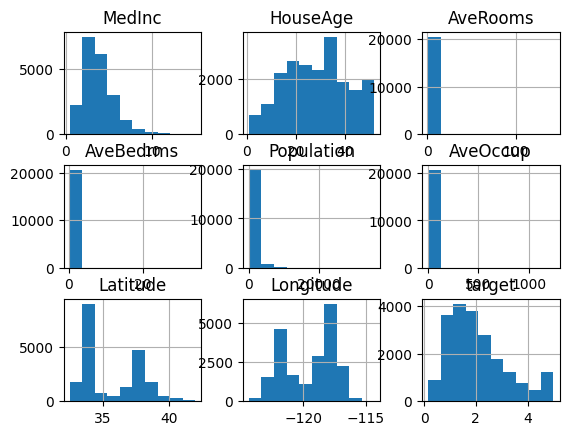

In [37]:
df.hist()

In [29]:
df.duplicated().sum()

np.int64(0)

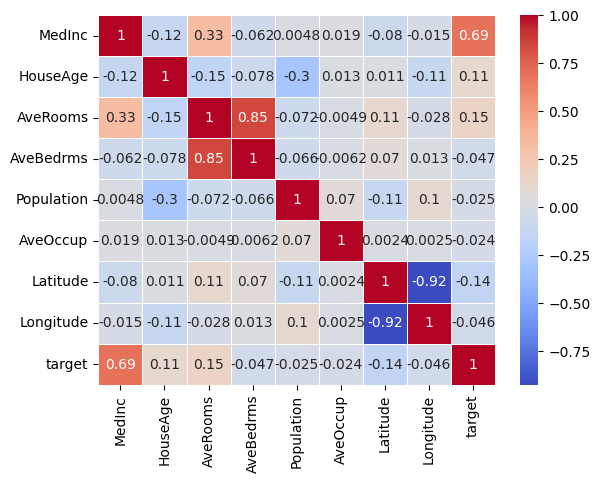

In [76]:
from seaborn.palettes import color_palette
df.corr()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()


In [38]:
iqr = df.quantile(0.75) - df.quantile(0.25)
lower_bound = df.quantile(0.25) - (1.5 * iqr)
upper_bound = df.quantile(0.75) + (1.5 * iqr)
df = df.clip(lower=lower_bound, upper=upper_bound,axis=1)


In [39]:
df.skew()

,0
MedInc,0.735618
HouseAge,0.060331
AveRooms,0.348567
AveBedrms,0.462645
Population,0.842247
AveOccup,0.510453
Latitude,0.465953
Longitude,-0.297801
target,0.912330


In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df.drop('target', axis=1))

X_scaled = pd.DataFrame(X_scaled, columns=housing.feature_names)

print(X_scaled.head())

     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  2.344766  0.982143  0.628559  -0.153758   -0.974429 -0.049597  1.052548   
1  2.332238 -0.607019  0.327041  -0.263336    0.861439 -0.092512  1.043185   
2  1.782699  1.856182  1.155620  -0.049016   -0.820777 -0.025843  1.038503   
3  0.932968  1.856182  0.156966  -0.049833   -0.766028 -0.050329  1.038503   
4 -0.012881  1.856182  0.344711  -0.032906   -0.759847 -0.085616  1.038503   

   Longitude  
0  -1.327835  
1  -1.322844  
2  -1.332827  
3  -1.337818  
4  -1.337818  


In [60]:
# Train-test split
y=df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

X_scaled.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((20640, 8), (16512, 8), (4128, 8), (16512,), (4128,))

In [61]:
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

lr_score = lr.score(x_test_scaled, y_test)
print("Linear Regression R²:", lr_score)

Linear Regression R²: 0.575787706032451


In [63]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train_scaled, y_train)

dt_score = dt.score(x_test_scaled, y_test)
print("Decision Tree R²:", dt_score)

Decision Tree R²: 0.6230424613065773


In [67]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(x_train_scaled, y_train)

rf_score = rf.score(x_test_scaled, y_test)
print("Random Forest R²:", rf_score)

Random Forest R²: 0.8052747336256919


In [58]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

gb_score = gb.score(X_test, y_test)
print("Gradient Boosting R²:", gb_score)

Gradient Boosting R²: 0.7756433164710084


In [66]:
from sklearn.svm import SVR

svr = SVR()
svr.fit(x_train_scaled, y_train)

svr_score = svr.score(x_test_scaled, y_test)
print("SVR R²:", svr_score)

SVR R²: 0.727562892301679


In [68]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    return mse, mae, r2

In [70]:
results = {}

# Linear Regression
results['Linear Regression'] = evaluate_model(lr, x_test_scaled, y_test)

# Decision Tree
results['Decision Tree'] = evaluate_model(dt, x_test_scaled, y_test)

# Random Forest
results['Random Forest'] = evaluate_model(rf, x_test_scaled, y_test)

# Gradient Boosting
results['Gradient Boosting'] = evaluate_model(gb, x_test_scaled, y_test)

# SVR
results['SVR'] = evaluate_model(svr, x_test_scaled, y_test)



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [71]:
# Display Results
for model, (mse, mae, r2) in results.items():
    print(f"{model}")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print("-"*30)

Linear Regression
MSE: 0.5559
MAE: 0.5332
R²: 0.5758
------------------------------
Decision Tree
MSE: 0.4940
MAE: 0.4539
R²: 0.6230
------------------------------
Random Forest
MSE: 0.2552
MAE: 0.3274
R²: 0.8053
------------------------------
Gradient Boosting
MSE: 0.2979
MAE: 0.3719
R²: 0.7727
------------------------------
SVR
MSE: 0.3570
MAE: 0.3986
R²: 0.7276
------------------------------
